In [1]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
print("true")

true


In [2]:
df=pd.read_csv('Summer Project - Form Responses.3 1 (2).csv')
print(df.head())
df.count()

           Timestamp  What is your age What is your gender  \
0  7/9/2025 14:46:09              23.0              Female   
1  7/9/2025 14:55:10              21.0              Female   
2  7/9/2025 14:58:09              22.0                Male   
3  7/9/2025 14:59:45              22.0              Female   
4  7/9/2025 15:01:41              24.0                Male   

  What is your current qualification status  \
0                      Working Professional   
1                             Post graduate   
2                             Post graduate   
3                             Post graduate   
4                            Under graduate   

  Which of the following categories do you spend willingly or spend regularly on (Choose all that applies to the question, at least choose 3)  \
0  Transportation.      (Petrol/Diesel/Public Mod...                                                                                            
1  Lifestyle & Self-Care.    (Fashion & Grooming/...  

Timestamp                                                                                                                                                                                                               252
What is your age                                                                                                                                                                                                        249
What is your gender                                                                                                                                                                                                     252
What is your current qualification status                                                                                                                                                                               245
Which of the following categories do you spend willingly or spend regularly on (Choose all that applies to the question,

In [3]:
print(df.isnull().sum())
df=df.dropna()

Timestamp                                                                                                                                                                                                               1
What is your age                                                                                                                                                                                                        4
What is your gender                                                                                                                                                                                                     1
What is your current qualification status                                                                                                                                                                               8
Which of the following categories do you spend willingly or spend regularly on (Choose all that applies to the question, at leas

In [4]:
#labelencoder 
le=LabelEncoder()
df['Q6_encoded']=df['When buying something you want (not need) which statements describe you the best'].replace({
    'I buy it immediately without thinking much':0,
    'I think for a while, but mostly end up buying':1,
    'I wait and save up for it before buying':2,
    'I often decide not to buy it at all':3})
print("true")

true


/var/folders/l8/4nsp6vdj325frh0fd40tv8_40000gn/T/ipykernel_70974/2486296071.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Q6_encoded']=df['When buying something you want (not need) which statements describe you the best'].replace({


In [5]:
#Q12
df['Q12_encoded'] = df['Which of these best describes your approach to saving '].replace({
    'I save systematically as a priority': 0,
    'I save whatever is left after spending': 1,
    'I rarely think about saving': 2,
    'I dont save, I prefer spending in the present': 3})
print("true")

true


/var/folders/l8/4nsp6vdj325frh0fd40tv8_40000gn/T/ipykernel_70974/137165465.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Q12_encoded'] = df['Which of these best describes your approach to saving '].replace({


In [6]:
#Q13 
df['Q13_encoded'] = df['Imagine you see a new phone model launched that you really like. What\'s your first thought (Even if you are not spending your own money but rely on your parents, Answer as per your current status and convenience)'].replace({
    'I will try to buy it as soon as possible': 0,
    'I will wait for the price to drop or offers': 1,
    'I will plan to buy it if it as a necessity and not a liability': 2})
print("true")

true


/var/folders/l8/4nsp6vdj325frh0fd40tv8_40000gn/T/ipykernel_70974/3670089984.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Q13_encoded'] = df['Imagine you see a new phone model launched that you really like. What\'s your first thought (Even if you are not spending your own money but rely on your parents, Answer as per your current status and convenience)'].replace({


In [7]:
def assign_spender_type(row):
    scores = {'Impulsive': 0, 'Balanced': 0, 'Planner/Saver': 0, 'Frugal': 0}
#Q6 SCORING
    if row['Q6_encoded'] == 0:
        scores['Impulsive'] += 2
    elif row['Q6_encoded'] == 1:
        scores['Balanced'] += 2
        scores['Planner/Saver'] += 1
    elif row['Q6_encoded'] == 2:
        scores['Planner/Saver'] += 2
        scores['Frugal'] += 1
    elif row['Q6_encoded'] == 3:
        scores['Frugal'] += 2

#Q12 SCORING 
    if row['Q12_encoded']==0:
        scores['Planner/Saver']+=2
        scores['Frugal']+=1
    elif row['Q12_encoded']==1:
        scores['Balanced']+=2
        scores['Planner/Saver']+=1
    elif row['Q12_encoded']==2:
        scores['Impulsive']+=2
    elif row['Q12_encoded']==3:
        scores['Impulsive']+=3

#Q13 SCORING
    if row['Q13_encoded']==0:
        scores['Impulsive']+=2
    elif row['Q13_encoded']==1:
        scores['Balanced']+=2
        scores['Impulsive']+=1
    elif row['Q13_encoded']==2:
        scores['Planner/Saver']+=2
    elif row['Q13_encoded']==3:
        scores['Frugal']+=2
    return max(scores,key=scores.get)

df['Spender_Type']=df.apply(assign_spender_type, axis=1)
print(df['Spender_Type'].value_counts())

Spender_Type
Planner/Saver    148
Balanced          50
Impulsive         30
Frugal             8
Name: count, dtype: int64


In [8]:
print("Missing Q6:", df['Q6_encoded'].isnull().sum())
print("Missing Q12:", df['Q12_encoded'].isnull().sum())
print("Missing Q13:", df['Q13_encoded'].isnull().sum())
df

Missing Q6: 0
Missing Q12: 0
Missing Q13: 0


,Timestamp,What is your age,What is your gender,What is your current qualification status,"Which of the following categories do you spend willingly or spend regularly on (Choose all that applies to the question, at least choose 3)","If you received an extra ₹10,000 today, what would be your TOP THREE spending priorities? (Choose up to 3)",When buying something you want (not need) which statements describe you the best,"When your friends colleagues buy something expensive you like, what is your reaction to it","If your monthly income was reduced by half, which THREE categories would you cut down spending on first? (Choose three)","If your monthly income doubled, what is the FIRST category you would increase spending on?",...,Which of these best describes your approach to saving,"Imagine you see a new phone model launched that you really like. What's your first thought (Even if you are not spending your own money but rely on your parents, Answer as per your current status and convenience)","If your monthly expenses suddenly increased unexpectedly (e.g. medical, college fees), what would you do first?",Do you usually keep track of your expenses?,Which spending mode do you prefer for daily spending,While choosing what to spend on whose opinion matters the most?,Q6_encoded,Q12_encoded,Q13_encoded,Spender_Type
0,7/9/2025 14:46:09,23.0,Female,Working Professional,Transportation. (Petrol/Diesel/Public Mod...,Savings & Investments,I wait and save up for it before buying,It doesn’t affect my decisions,"Health & Wellness. (Gym/Yoga/Sports), Life...",Savings & Investments,...,I save systematically as a priority,I will wait for the price to drop or offers,Cut down on lifestyle and leisure expenses,"Yes, absolutely",UPI,Family,2,0,1,Planner/Saver
1,7/9/2025 14:55:10,21.0,Female,Post graduate,Lifestyle & Self-Care. (Fashion & Grooming/...,Lifestyle & Self-Care. (Fashion & Grooming/...,I often decide not to buy it at all,It doesn’t affect my decisions,Social Spending. (Birthday Parties/Birthda...,Savings & Investments,...,I save systematically as a priority,I will plan to buy it if it as a necessity and...,Cut down on lifestyle and leisure expenses,Rarely,UPI,I am an independent spender and hence I decide...,3,0,2,Planner/Saver
2,7/9/2025 14:58:09,22.0,Male,Post graduate,Transportation. (Petrol/Diesel/Public Mode),Savings & Investments,I wait and save up for it before buying,I plan to buy it later when affordable,Lifestyle & Self-Care. (Fashion & Grooming/...,Savings & Investments,...,I save whatever is left after spending,I will wait for the price to drop or offers,Cut down on lifestyle and leisure expenses,Rarely,UPI,I am an independent spender and hence I decide...,2,1,1,Balanced
3,7/9/2025 14:59:45,22.0,Female,Post graduate,"Food & Living (Outings with friends, Family)",Lifestyle & Self-Care. (Fashion & Grooming/...,I wait and save up for it before buying,I admire it but don’t plan to buy,Social Spending. (Birthday Parties/Birthda...,Savings & Investments,...,I save systematically as a priority,I will plan to buy it if it as a necessity and...,Cut down on lifestyle and leisure expenses,"Yes, absolutely",UPI,Family,2,0,2,Planner/Saver
4,7/9/2025 15:01:41,24.0,Male,Under graduate,Transportation. (Petrol/Diesel/Public Mod...,"Health & Wellness. (Gym/Yoga/Sports), Life...",I often decide not to buy it at all,It doesn’t affect my decisions,Social Spending. (Birthday Parties/Birthda...,Savings & Investments,...,I save systematically as a priority,I will plan to buy it if it as a necessity and...,Cut down on lifestyle and leisure expenses,Only the extra expenses that happen over a month,UPI,I am an independent spender and hence I decide...,3,0,2,Planner/Saver
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,9/22/2025 12:52:23,22.0,Female,Post graduate,Transportation. (Petrol/Diesel/Public Mod...,"Health & Wellness. (Gym/Yoga/Sports), Tran...","I think for a while, but mostly end up buying",I admire it b

In [9]:
#Machine learning prepaering features and targets 
X=df[['Q6_encoded','Q12_encoded','Q13_encoded']]
y=df['Spender_Type']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9791666666666666
               precision    recall  f1-score   support

     Balanced       1.00      1.00      1.00         9
       Frugal       1.00      1.00      1.00         2
    Impulsive       1.00      0.86      0.92         7
Planner/Saver       0.97      1.00      0.98        30

     accuracy                           0.98        48
    macro avg       0.99      0.96      0.98        48
 weighted avg       0.98      0.98      0.98        48



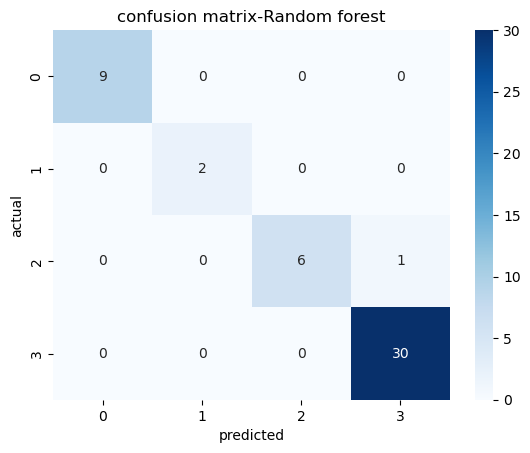

In [11]:
#Confusion matrix
cm_rf=confusion_matrix(y_test,y_pred_rf)
sns.heatmap(cm_rf,annot=True,fmt="d",cmap="Blues")
plt.title("confusion matrix-Random forest")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

In [12]:
dt=DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt=dt.predict(X_test)

print("Decison Tree Accuracy:",accuracy_score(y_test,y_pred_dt))
print(classification_report(y_test,y_pred_dt))

Decison Tree Accuracy: 0.9791666666666666
               precision    recall  f1-score   support

     Balanced       1.00      1.00      1.00         9
       Frugal       1.00      1.00      1.00         2
    Impulsive       1.00      0.86      0.92         7
Planner/Saver       0.97      1.00      0.98        30

     accuracy                           0.98        48
    macro avg       0.99      0.96      0.98        48
 weighted avg       0.98      0.98      0.98        48



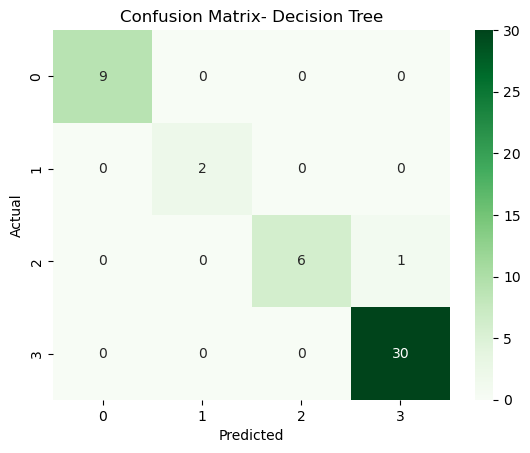

In [13]:
#Confusion Matrix For Decision Tree
cm_dt=confusion_matrix(y_test,y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d',cmap='Greens')
plt.title('Confusion Matrix- Decision Tree')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test,y_pred_lr))
print(classification_report(y_test,y_pred_lr))

Logistic Regression Accuracy: 0.6875
               precision    recall  f1-score   support

     Balanced       0.00      0.00      0.00         9
       Frugal       0.00      0.00      0.00         2
    Impulsive       0.83      0.71      0.77         7
Planner/Saver       0.74      0.93      0.82        30

     accuracy                           0.69        48
    macro avg       0.39      0.41      0.40        48
 weighted avg       0.58      0.69      0.63        48



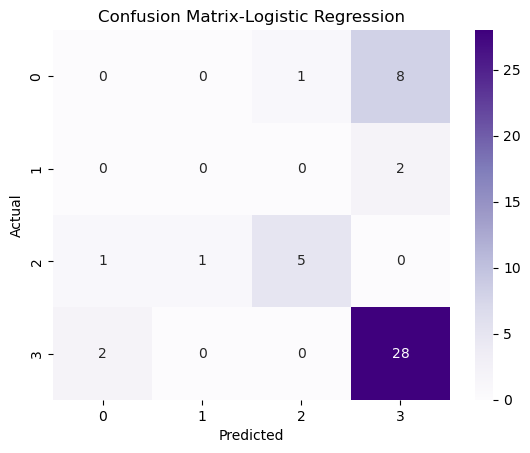

In [15]:
#Confusion Matrix for Logistic Regression 
cm_lr=confusion_matrix(y_test,y_pred_lr)
sns.heatmap(cm_lr,annot=True,fmt="d",cmap="Purples")
plt.title('Confusion Matrix-Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [16]:

from sklearn.model_selection import train_test_split
for seed in [1, 5, 10, 20, 50]:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
    rf.fit(X_train, y_train)
    acc = rf.score(X_test, y_test)
    print(f"Random seed {seed} -> Accuracy: {acc:.2f}")


from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(rf, X, y, cv=5)
print("Cross-validation accuracy:", cv_scores)
print("Average CV Accuracy:",cv_scores.mean())

Random seed 1 -> Accuracy: 0.98
Random seed 5 -> Accuracy: 0.92
Random seed 10 -> Accuracy: 1.00
Random seed 20 -> Accuracy: 0.94
Random seed 50 -> Accuracy: 0.98
Cross-validation accuracy: [0.97916667 0.9787234  0.9787234  0.91489362 1.        ]
Average CV Accuracy: 0.9703014184397162


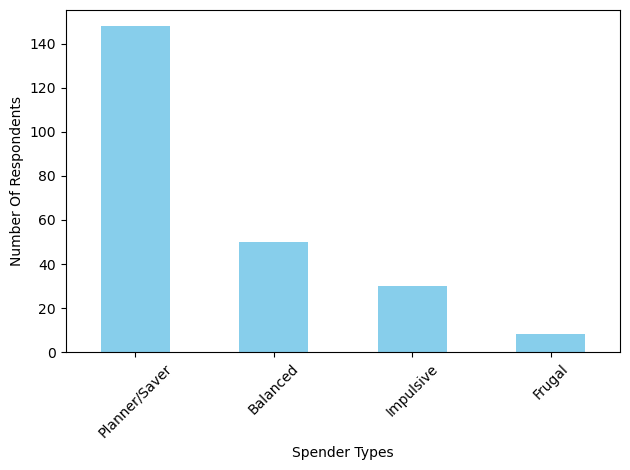

In [17]:
#Distribution of spender types 
import matplotlib.pyplot as plt
df['Spender_Type'].value_counts().plot(kind="bar",color=("skyblue"))
plt.xlabel('Spender Types')
plt.ylabel('Number Of Respondents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

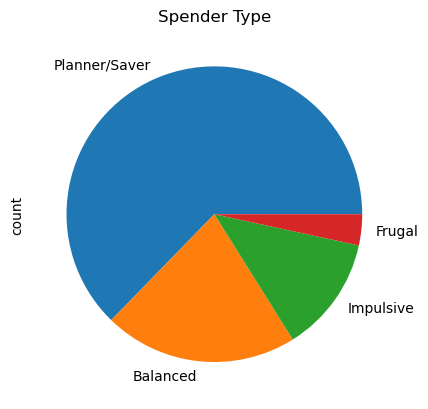

In [18]:
#Pie Chart
df['Spender_Type'].value_counts().plot(kind="pie",color="skyblue")
plt.title('Spender Type')
plt.show()

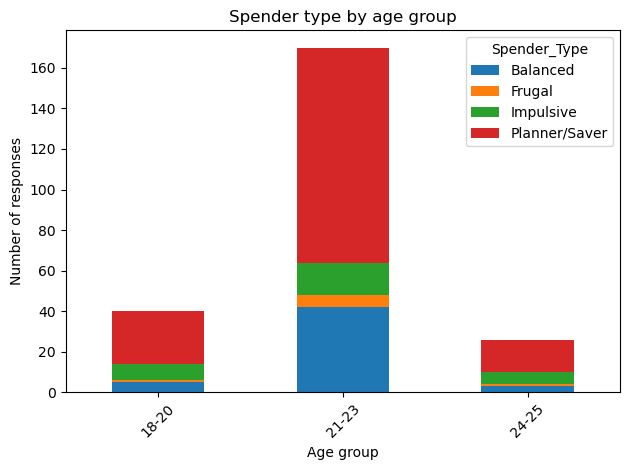

In [19]:
#Spender type by age group
df['age_group']=pd.cut(df['What is your age'],bins=[17,20,23,25],labels=['18-20','21-23','24-25'])
pd.crosstab(df['age_group'],df['Spender_Type']).plot(kind='bar',stacked=True)
plt.title('Spender type by age group')
plt.xlabel('Age group')
plt.ylabel('Number of responses')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()                                                           

In [20]:
import joblib

joblib.dump(rf, "random_forest_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [21]:
q6_map={"I buy it immediately without thinking much":0,
        "I think for a while but mostly end up buying it":1,
        "I wait and save up for it before buying":2,
        "I often decide to nit buy it at all":3}
q12_map={"I save systematically as a prirority":0,
         "I save whatever is left after spending":1,
         "I rarely think about saving":2,
         "I do not save, I prefer spending in the present":3}
q13_map={"I will try to buy it as soon as possible": 0,
         'I will wait for the price to drop or offers': 1,
         'I will plan to buy it if it as a necessity and not a liability': 2}

In [22]:
print("Welcome to GEN-Z spending pattern Predictor")

Welcome to GEN-Z spending pattern Predictor


In [ ]:
print("Q6: When buying something you want (not need) which statement describes you the best")
print("1.I buy it immediately without thinking much")
print("2.I think for a while but mostly end up buying it")
print("3.I wait and save up for it before buying")
print("4.I often decide to nit buy it at all")
q6_choice=int(input("Enter choice 1-4:"))

print('Q12: Which of these best describes your approach to saving ')
print('1.I save systematically as a priority')
print('2.I save whatever is left after spending')
print('3.I rarely think about saving')
print('4.I dont save, I prefer spending in the present')
q12_choice=int(input("Enter choice 1-4:"))

print('Imagine you see a new phone model launched that you really like. What\'s your first thought (Even if you are not spending your own money but rely on your parents, Answer as per your current status and convenience')
print('1.I will try to buy it as soon as possible')
print('2.I will wait for the price to drop or offers')
print('3.I will plan to buy it if it as a necessity and not a liability')
q13_choice=int(input("Enter choice 1-3:"))

print("executed")

user_q6 = list(q6_map.values())[q6_choice - 1]
user_q12 = list(q12_map.values())[q12_choice - 1]
user_q13 = list(q13_map.values())[q13_choice - 1]

user_df = pd.DataFrame([[user_q6, user_q12, user_q13]],
                       columns=["Q6_encoded", "Q12_encoded", "Q13_encoded"])

prediction = rf.predict(user_df)

spender_types = ["Impulsive", "Balanced", "Planner/Saver", "Frugal"]

print("\nPredicted Spender Type:", prediction[0])

Q6: When buying something you want (not need) which statement describes you the best
1.I buy it immediately without thinking much
2.I think for a while but mostly end up buying it
3.I wait and save up for it before buying
4.I often decide to nit buy it at all
